<a href="https://colab.research.google.com/github/AnabelGP/An-lisis-estad-stico-b-sico/blob/main/Caso_pr%C3%A1ctico_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caso práctico: Análisis electromiográfico
**Nombre:** Anabel Gallego Pérez

**Fecha:** 06/04/2026

**Versión de Python:** 3.14.3

**Contacto:** anabelgallego.fisioterapeuta@gmail.com

**Descripción:** Este programa está orientado a la generación de gráficas para el estudio de las señales electromiográficas de una persona en un experimento de imaginería motora. Se utilizó un instrumento llamado muse2 en el que se conectan electrodos directamentre en la cabeza del sujeto. Se tomaron las bandas de frecuencia cerebral delta (0.5 - 4 Hz), theta (4 - 8 Hz), Alpha (8 - 12 Hz), Beta (12 - 30 Hz) y Gamma (30 - 45 Hz). Los electrodos son denotados como TP9 (lateral izquierdo), AF7 (frontal izquierdo), AF8 (frontal derecho) y TP10 (lateral derecho). Además, se recopilan señales RAW, sin procesar y el marcador auziliar AUX_RIGHT. Se presentan indicacores de tranquilidad "MELLOW" y concentración "Concentration" (ambos con valores de 0 a 1). Finalmente, se colocan sensores de movimiento (acelerómetro y giroscopio) control de calidad del dispositivo (HSI -> Headband Signal Integrity (0 mal contacto y 1 buen contacto). HeadBandOn --> ¿Está bien colocada la banda? y Baterry --> Porcentaje de batería).

## Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Variables globales

In [ ]:
# Electrodos del electromiografo
electrodos = ["TP10", "TP9", "AF7", "AF8"]

# Parámetros de matplotlib
plt.rcParams.update({"font.size": 12, "font.family":"Times New Roman"}) # Cambiamos tamaño y estilo del texto

## Funciones

In [ ]:
# Función para transformar los datos de fecha a minutos
def dato_fecha(lista):
    resultados = []
    for elemento in lista:
        # Los valores de minutos son el segundo valor [1] y de segundos el tercero [2]
        valor = float(elemento.split(":")[1]) + (float(elemento.split(":")[2])/60)
        resultados.append(valor)
    return np.array(resultados) # Minutos en un array de numpy

## Importación y análisis exploratorio

In [ ]:
# Importación de la base de datos

df = pd.read_csv("dataset_semana7.csv")

df.head() # El fallo que da es porque se le dificulta saber que tipo de datos presenta una o varias columnas de la base de datos, pero al imprimir vemos que es solo una y que no es relevante

C:\Users\agallegop\AppData\Local\Temp\ipykernel_28188\1757053263.py:3: DtypeWarning: Columns (0: Elements) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataset_semana7.csv")


,TimeStamp,Delta_TP9,Delta_AF7,Delta_AF8,Delta_TP10,Theta_TP9,Theta_AF7,Theta_AF8,Theta_TP10,Alpha_TP9,...,Gyro_X,Gyro_Y,Gyro_Z,HeadBandOn,HSI_TP9,HSI_AF7,HSI_AF8,HSI_TP10,Battery,Elements
0,2024-06-05 17:23:37.961,0.329342,-0.259216,-0.090011,0.551984,0.427443,-0.264384,-0.045775,0.591313,1.004643,...,0.276642,0.18692,-0.986938,1.0,1.0,1.0,1.0,1.0,80.0,NaN
1,2024-06-05 17:23:37.967,0.329342,-0.259216,-0.090011,0.551984,0.427443,-0.264384,-0.045775,0.591313,1.004643,...,0.276642,0.18692,-0.986938,1.0,1.0,1.0,1.0,1.0,80.0,NaN
2,2024-06-05 17:23:37.968,0.329342,-0.259216,-0.090011,0.551984,0.427443,-0.264384,-0.045775,0.591313,1.004643,...,0.276642,0.18692,-0.986938,1.0,1.0,1.0,1.0,1.0,80.0,NaN
3,2024-06-05 17:23:37.969,0.329342,-0.259216,-0.090011,0.551984,0.427443,-0.264384,-0.045775,0.591313,1.004643,...,0.276642,0.18692,-0.986938,1.0,1.0,1.0,1.0,1.0,80.0,NaN
4,2024-06-05 17:23:37.969,0.329342,-0.259216,-0.090011,0.551984,0.427443,-0.264384,-0.045775,0.591313,1.004643,...,0.276642,0.18692,-0.986938,1.0,1.0,1.0,1.0,1.0,80.0,NaN


In [ ]:
# Información de los datos de cada columnas de la base de datos importada

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 129164 entries, 0 to 129163
Data columns (total 41 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TimeStamp        129164 non-null  str    
 1   Delta_TP9        129036 non-null  float64
 2   Delta_AF7        129036 non-null  float64
 3   Delta_AF8        129036 non-null  float64
 4   Delta_TP10       129036 non-null  float64
 5   Theta_TP9        129036 non-null  float64
 6   Theta_AF7        129036 non-null  float64
 7   Theta_AF8        129036 non-null  float64
 8   Theta_TP10       129036 non-null  float64
 9   Alpha_TP9        129036 non-null  float64
 10  Alpha_AF7        129036 non-null  float64
 11  Alpha_AF8        129036 non-null  float64
 12  Alpha_TP10       129036 non-null  float64
 13  Beta_TP9         129036 non-null  float64
 14  Beta_AF7         129036 non-null  float64
 15  Beta_AF8         129036 non-null  float64
 16  Beta_TP10        129036 non-null  float64
 17  Ga

Estamos ante una base de datos que presenta datos nulos, por lo que haremos un análisis posterior de ellos. Además, observamos que la mayor parte de los datos son datos numéricos con decimales

In [ ]:
# Análisis numérico descriptivo general básico de la base de datos

df.describe()

,Delta_TP9,Delta_AF7,Delta_AF8,Delta_TP10,Theta_TP9,Theta_AF7,Theta_AF8,Theta_TP10,Alpha_TP9,Alpha_AF7,...,Accelerometer_Z,Gyro_X,Gyro_Y,Gyro_Z,HeadBandOn,HSI_TP9,HSI_AF7,HSI_AF8,HSI_TP10,Battery
count,129036.000000,129036.000000,129036.000000,129036.000000,129036.000000,129036.000000,129036.000000,129036.000000,129036.000000,129036.000000,...,129036.000000,129036.000000,129036.000000,129036.000000,129036.0,129036.000000,129036.0,129036.0,129036.000000,129036.000000
mean,0.342180,0.124384,0.077540,0.352325,0.253640,0.018894,-0.037260,0.321938,0.731399,0.381510,...,0.849910,-0.113184,-1.685535,-0.381239,1.0,1.083217,1.0,1.0,1.083217,76.312657
std,0.283646,0.323392,0.297897,0.281858,0.278554,0.266383,0.199776,0.231199,0.327303,0.186648,...,0.019396,0.418749,0.813371,0.747655,0.0,0.276211,0.0,0.0,0.276211,2.200058
min,-0.392089,-0.741858,-0.679916,-0.393369,-0.482254,-0.600334,-0.684252,-0.313269,-0.287308,-0.327800,...,0.763733,-6.721649,-7.289886,-12.269440,1.0,1.000000,1.0,1.0,1.000000,75.000000
25%,0.159408,-0.103720,-0.121878,0.158172,0.090665,-0.160413,-0.167679,0.177774,0.476288,0.260018,...,0.840942,-0.269165,-2.056122,-0.628052,1.0,1.000000,1.0,1.0,1.000000,75.000000
50%,0.320674,0.064753,0.033071,0.338531,0.248604,-0.021164,-0.039023,0.301861,0.759584,0.374275,...,0.853394,-0.104675,-1.727142,-0.366364,1.0,1.000000,1.0,1.0,1.000000,75.000000
75%,0.487096,0.298579,0.216467,0.505652,0.401091,0.143175,0.073189,0.422052,1.001632,0.506403,...,0.862061,0.044861,-1.383209,-0.119629,1.0,1.000000,1.0,1.0,1.000000,80.000000
max,1.571082,1.229602,1.195198,1.361122,1.668064,1.183985,0.751333,1.388208,1.414755,1.062203,...,0.906067,5.734711,11.147919,9.106750,1.0,2.000000,1.0,1.0,2.000000,80.000000


In [ ]:
df[["Alpha_TP9", "Alpha_AF7", "Concentration"]].describe()

,Alpha_TP9,Alpha_AF7,Concentration
count,129036.000000,129036.000000,129036.00000
mean,0.731399,0.381510,58.32202
std,0.327303,0.186648,46.91879
min,-0.287308,-0.327800,0.00000
25%,0.476288,0.260018,0.00000
50%,0.759584,0.374275,100.00000
75%,1.001632,0.506403,100.00000
max,1.414755,1.062203,100.00000


## Análisis de valores nulos

In [ ]:
# Contamos la cantidad de datos nulos de las columnas

df.isnull().sum()

TimeStamp               0
Delta_TP9             128
Delta_AF7             128
Delta_AF8             128
Delta_TP10            128
Theta_TP9             128
Theta_AF7             128
Theta_AF8             128
Theta_TP10            128
Alpha_TP9             128
Alpha_AF7             128
Alpha_AF8             128
Alpha_TP10            128
Beta_TP9              128
Beta_AF7              128
Beta_AF8              128
Beta_TP10             128
Gamma_TP9             128
Gamma_AF7             128
Gamma_AF8             128
Gamma_TP10            128
RAW_TP9               128
RAW_AF7               128
RAW_AF8               128
RAW_TP10              128
AUX_RIGHT             128
Mellow                128
Concentration         128
Accelerometer_X       128
Accelerometer_Y       128
Accelerometer_Z       128
Gyro_X                128
Gyro_Y                128
Gyro_Z                128
HeadBandOn            128
HSI_TP9               128
HSI_AF7               128
HSI_AF8               128
HSI_TP10    

Observamos que la columna "Elements" presenta la mayor parte de sus datos como nulos. Si eliminamos los datos directamente, sin eliminar esta columna, nos quedamos sin datos en la base de datos, por lo que hay que eliminar esta columna primero

In [ ]:
# Eliminamos al columna "Elements" y redefinimos el DataFrame

df = df.drop("Elements", axis = 1) # Para que el comando comprenda que "Elements" es una columna, hay que poner 'axis = 1'
df.head()

,TimeStamp,Delta_TP9,Delta_AF7,Delta_AF8,Delta_TP10,Theta_TP9,Theta_AF7,Theta_AF8,Theta_TP10,Alpha_TP9,...,Accelerometer_Z,Gyro_X,Gyro_Y,Gyro_Z,HeadBandOn,HSI_TP9,HSI_AF7,HSI_AF8,HSI_TP10,Battery
0,2024-06-05 17:23:37.961,0.329342,-0.259216,-0.090011,0.551984,0.427443,-0.264384,-0.045775,0.591313,1.004643,...,0.865723,0.276642,0.18692,-0.986938,1.0,1.0,1.0,1.0,1.0,80.0
1,2024-06-05 17:23:37.967,0.329342,-0.259216,-0.090011,0.551984,0.427443,-0.264384,-0.045775,0.591313,1.004643,...,0.865723,0.276642,0.18692,-0.986938,1.0,1.0,1.0,1.0,1.0,80.0
2,2024-06-05 17:23:37.968,0.329342,-0.259216,-0.090011,0.551984,0.427443,-0.264384,-0.045775,0.591313,1.004643,...,0.865723,0.276642,0.18692,-0.986938,1.0,1.0,1.0,1.0,1.0,80.0
3,2024-06-05 17:23:37.969,0.329342,-0.259216,-0.090011,0.551984,0.427443,-0.264384,-0.045775,0.591313,1.004643,...,0.865723,0.276642,0.18692,-0.986938,1.0,1.0,1.0,1.0,1.0,80.0
4,2024-06-05 17:23:37.969,0.329342,-0.259216,-0.090011,0.551984,0.427443,-0.264384,-0.045775,0.591313,1.004643,...,0.865723,0.276642,0.18692,-0.986938,1.0,1.0,1.0,1.0,1.0,80.0


## DataFrame sin valores nulos

In [ ]:
# Eliminamos los datos nulos del nuevo df
# DataFrame sin valores nulos

df = df.dropna()
df.head()

,TimeStamp,Delta_TP9,Delta_AF7,Delta_AF8,Delta_TP10,Theta_TP9,Theta_AF7,Theta_AF8,Theta_TP10,Alpha_TP9,...,Accelerometer_Z,Gyro_X,Gyro_Y,Gyro_Z,HeadBandOn,HSI_TP9,HSI_AF7,HSI_AF8,HSI_TP10,Battery
0,2024-06-05 17:23:37.961,0.329342,-0.259216,-0.090011,0.551984,0.427443,-0.264384,-0.045775,0.591313,1.004643,...,0.865723,0.276642,0.18692,-0.986938,1.0,1.0,1.0,1.0,1.0,80.0
1,2024-06-05 17:23:37.967,0.329342,-0.259216,-0.090011,0.551984,0.427443,-0.264384,-0.045775,0.591313,1.004643,...,0.865723,0.276642,0.18692,-0.986938,1.0,1.0,1.0,1.0,1.0,80.0
2,2024-06-05 17:23:37.968,0.329342,-0.259216,-0.090011,0.551984,0.427443,-0.264384,-0.045775,0.591313,1.004643,...,0.865723,0.276642,0.18692,-0.986938,1.0,1.0,1.0,1.0,1.0,80.0
3,2024-06-05 17:23:37.969,0.329342,-0.259216,-0.090011,0.551984,0.427443,-0.264384,-0.045775,0.591313,1.004643,...,0.865723,0.276642,0.18692,-0.986938,1.0,1.0,1.0,1.0,1.0,80.0
4,2024-06-05 17:23:37.969,0.329342,-0.259216,-0.090011,0.551984,0.427443,-0.264384,-0.045775,0.591313,1.004643,...,0.865723,0.276642,0.18692,-0.986938,1.0,1.0,1.0,1.0,1.0,80.0


## Transformación de los datos de tiempo

Queremos que los datos de tiempo estén en minutos

In [ ]:
# Cambiamos la columna de TimeStamp por los valores en minutos de la base de datos

df['TimeStamp'] = dato_fecha(df['TimeStamp'])
df.head()

,TimeStamp,Delta_TP9,Delta_AF7,Delta_AF8,Delta_TP10,Theta_TP9,Theta_AF7,Theta_AF8,Theta_TP10,Alpha_TP9,...,Accelerometer_Z,Gyro_X,Gyro_Y,Gyro_Z,HeadBandOn,HSI_TP9,HSI_AF7,HSI_AF8,HSI_TP10,Battery
0,23.632683,0.329342,-0.259216,-0.090011,0.551984,0.427443,-0.264384,-0.045775,0.591313,1.004643,...,0.865723,0.276642,0.18692,-0.986938,1.0,1.0,1.0,1.0,1.0,80.0
1,23.632783,0.329342,-0.259216,-0.090011,0.551984,0.427443,-0.264384,-0.045775,0.591313,1.004643,...,0.865723,0.276642,0.18692,-0.986938,1.0,1.0,1.0,1.0,1.0,80.0
2,23.632800,0.329342,-0.259216,-0.090011,0.551984,0.427443,-0.264384,-0.045775,0.591313,1.004643,...,0.865723,0.276642,0.18692,-0.986938,1.0,1.0,1.0,1.0,1.0,80.0
3,23.632817,0.329342,-0.259216,-0.090011,0.551984,0.427443,-0.264384,-0.045775,0.591313,1.004643,...,0.865723,0.276642,0.18692,-0.986938,1.0,1.0,1.0,1.0,1.0,80.0
4,23.632817,0.329342,-0.259216,-0.090011,0.551984,0.427443,-0.264384,-0.045775,0.591313,1.004643,...,0.865723,0.276642,0.18692,-0.986938,1.0,1.0,1.0,1.0,1.0,80.0


## Gráfico de bandas cerebrales respecto al tiempo

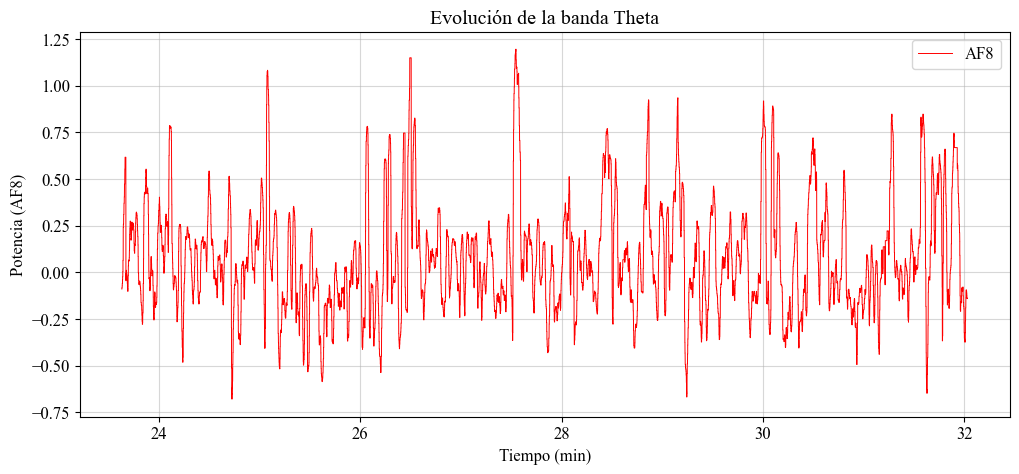

In [ ]:
plt.figure(figsize = (12, 5)) # Modificar el tamaño del gráfico
plt.plot(df['TimeStamp'], df['Delta_AF8'], linewidth = 0.7, color = 'Red', label = "AF8") # Generamos el gráfico con Tiempo en X y Potencia en Y, y cambiamos el grosor de la línea del gráfico, color y leyenda
plt.xlabel("Tiempo (min)") # Poner nombre al eje x
plt.ylabel("Potencia (AF8)") # Poner nombre al eje y
plt.title("Evolución de la banda Theta") # Poner título a los gráficos
plt.legend()
plt.grid(True, alpha = 0.5) # Colocamos la gráfica del fondo del gráfico y cambiamos la tonalidad (va de 0 a 1)

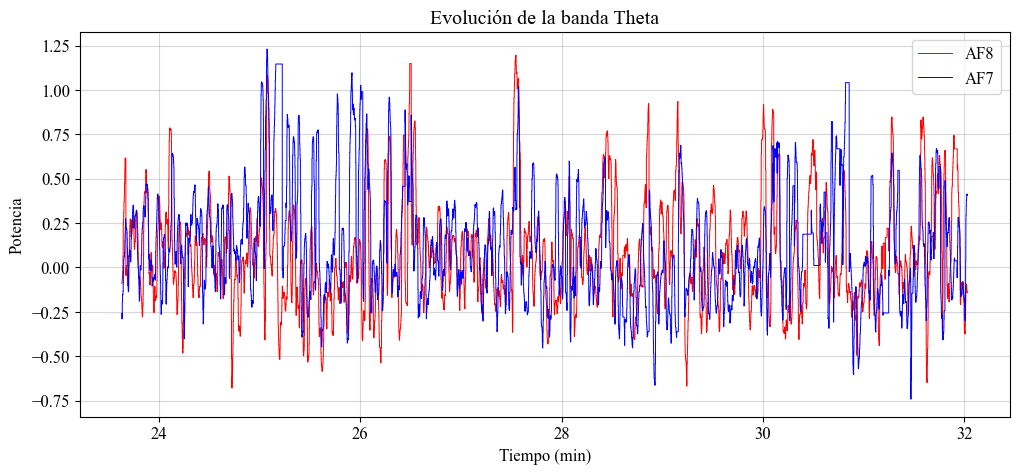

In [ ]:
plt.figure(figsize = (12, 5)) # Modificar el tamaño del gráfico
plt.plot(df['TimeStamp'], df['Delta_AF8'], linewidth = 0.7, color = 'Red', label = "AF8") # Generamos el gráfico con Tiempo en X y Potencia en Y, y cambiamos el grosor de la línea del gráfico, color y leyenda
plt.plot(df['TimeStamp'], df['Delta_AF7'], linewidth = 0.7, color = 'blue', label = "AF7")
plt.xlabel("Tiempo (min)") # Poner nombre al eje x
plt.ylabel("Potencia") # Poner nombre al eje y
plt.title("Evolución de la banda Theta") # Poner título a los gráficos
plt.legend()
plt.grid(True, alpha = 0.5) # Colocamos la gráfica del fondo del gráfico y cambiamos la tonalidad (va de 0 a 1)

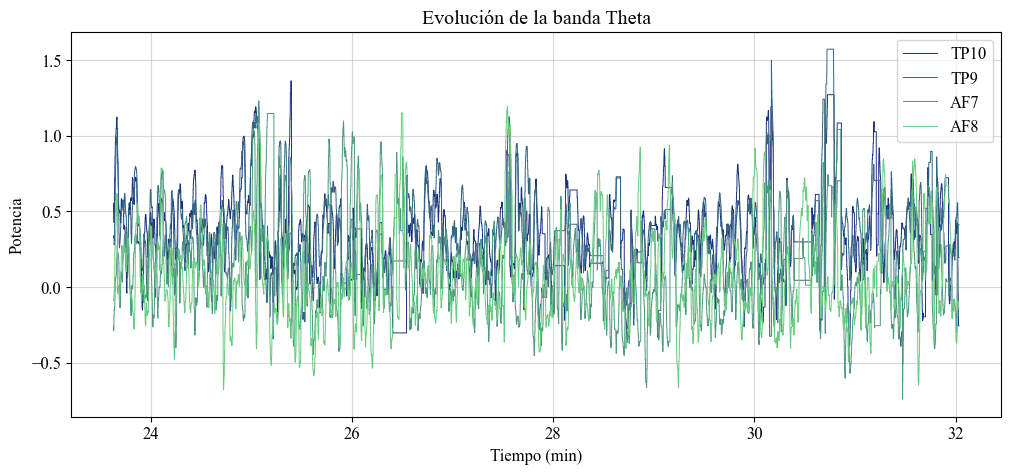

In [ ]:
plt.figure(figsize = (12, 5)) # Modificar el tamaño del gráfico
c = 0
for electrodo in electrodos:
    plt.plot(df['TimeStamp'], df[f"Delta_{electrodo}"], linewidth = 0.7, color = (0.1 + 0.1*c, 0.2 + 0.2*c, 0.5), label = f'{electrodo}')
    c = c + 1
plt.xlabel("Tiempo (min)") # Poner nombre al eje x
plt.ylabel("Potencia") # Poner nombre al eje y
plt.title("Evolución de la banda Theta") # Poner título a los gráficos
plt.legend()
plt.grid(True, alpha = 0.5) # Colocamos la gráfica del fondo del gráfico y cambiamos la tonalidad (va de 0 a 1)

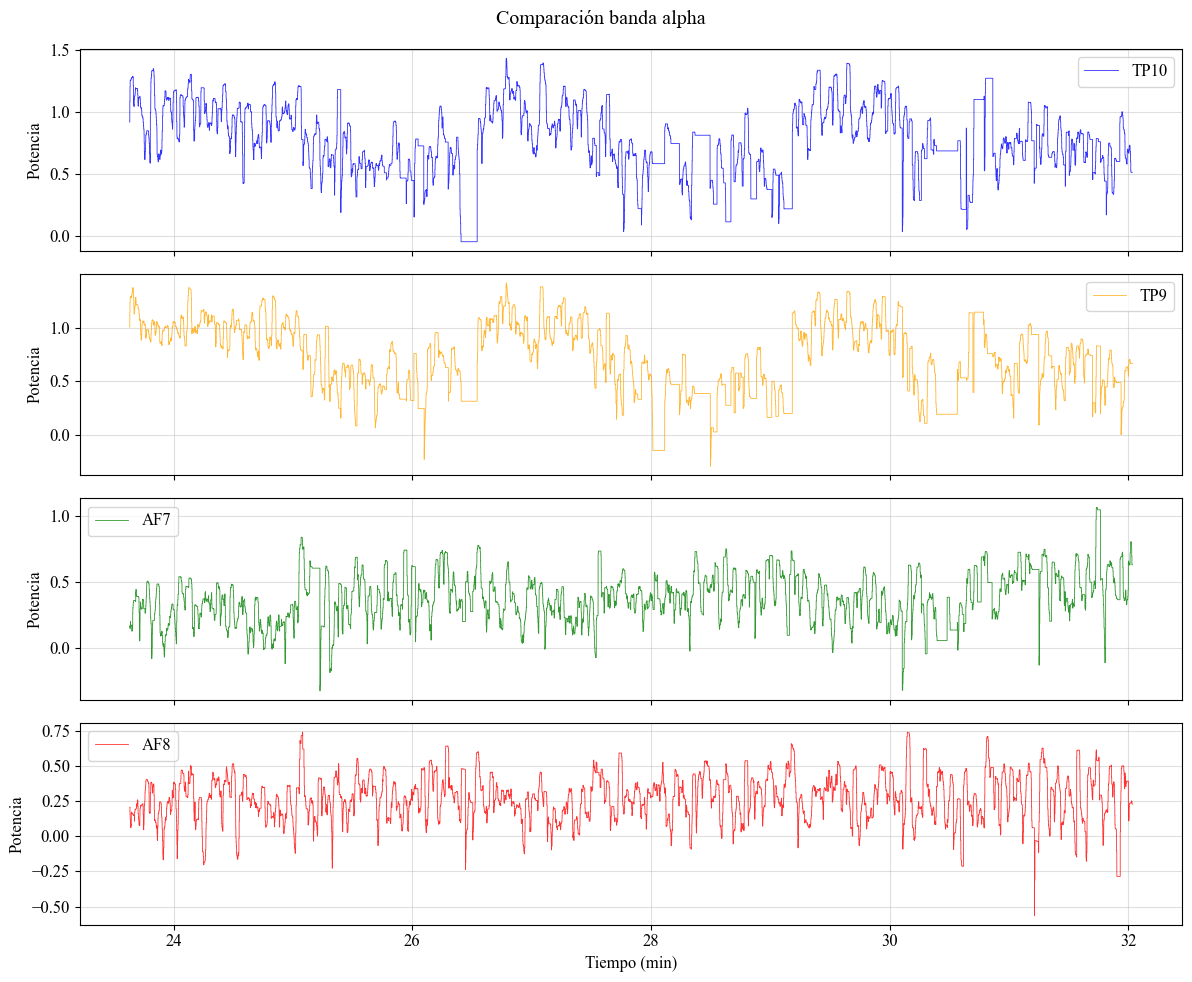

In [ ]:
fig, axes = plt.subplots(4, 1, figsize = (12, 10), sharex = True)
colores = ["blue", "orange", "green", "red"]

for i, electrodo in enumerate (electrodos):
    columna = f'Alpha_{electrodo}'
    axes[i].plot(df['TimeStamp'], df[columna],linewidth = 0.6, color = colores[i], alpha = 0.8, label = f'{electrodo}')
    axes[i].set_ylabel('Potencia')
    axes[i].grid(True, alpha = 0.4)
    axes[i].legend()

axes[-1].set_xlabel("Tiempo (min)")
fig.suptitle("Comparación banda alpha")
plt.tight_layout()
plt.show()

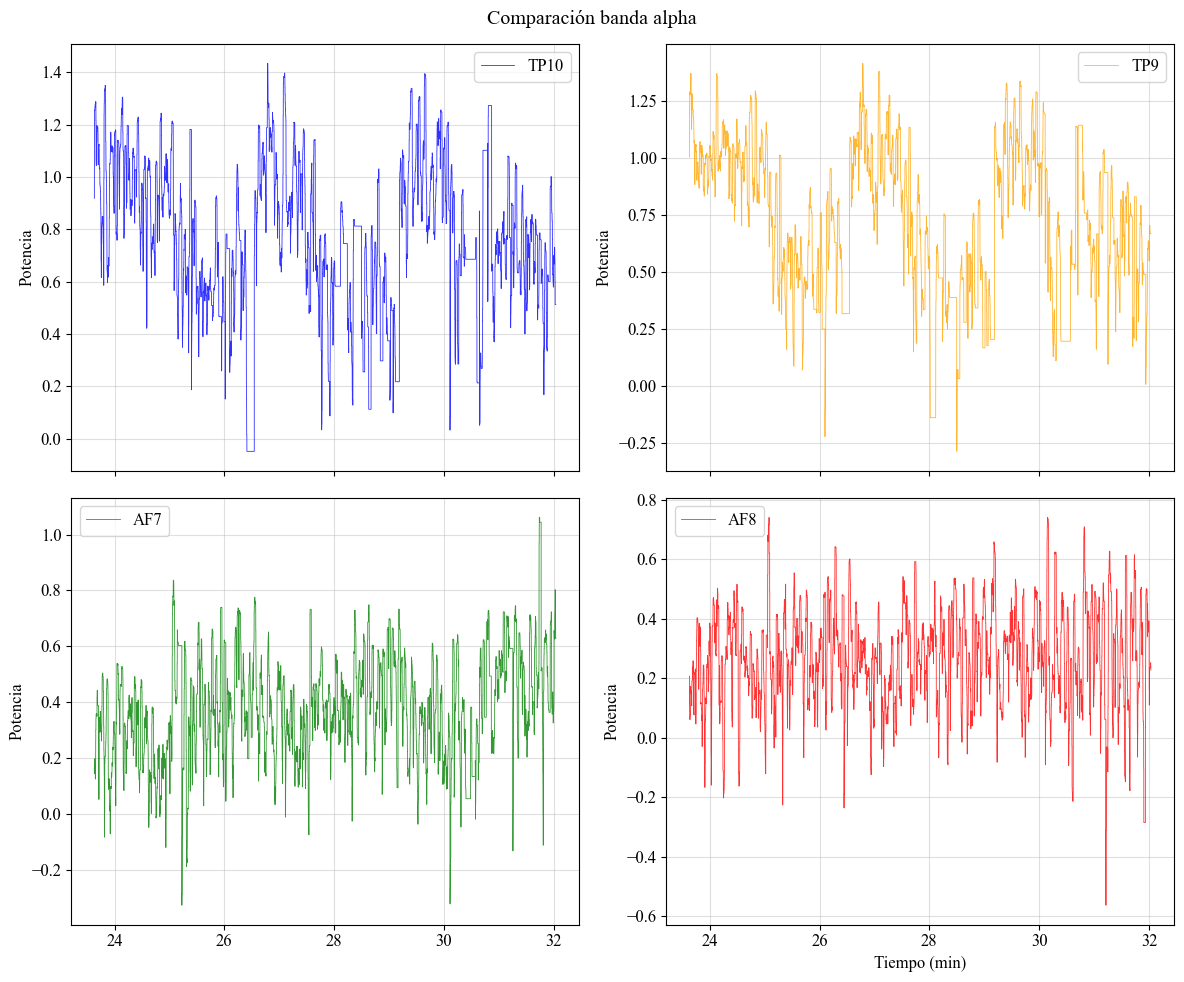

In [ ]:
fig, axes = plt.subplots(2, 2, figsize = (12, 10), sharex = True)
axes = axes.flatten() # Convertimos la matriz 2x2 en un array de 4 ejes
colores = ["blue", "orange", "green", "red"]

for i, electrodo in enumerate (electrodos):
    columna = f'Alpha_{electrodo}'
    axes[i].plot(df['TimeStamp'], df[columna],linewidth = 0.6, color = colores[i], alpha = 0.8, label = f'{electrodo}')
    axes[i].set_ylabel('Potencia')
    axes[i].grid(True, alpha = 0.4)
    axes[i].legend()

axes[-1].set_xlabel("Tiempo (min)")
fig.suptitle("Comparación banda alpha")
plt.tight_layout()
plt.show()

## Análisis de concentración

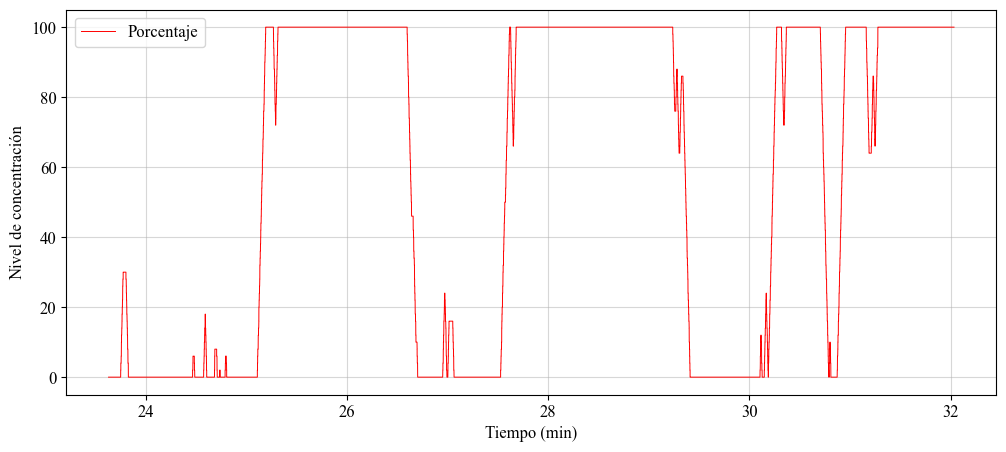

In [ ]:
plt.figure(figsize = (12, 5)) # Modificar el tamaño del gráfico
plt.plot(df['TimeStamp'], df['Concentration'], linewidth = 0.7, color = 'Red', label = "Porcentaje") # Generamos el gráfico con Tiempo en X y Potencia en Y, y cambiamos el grosor de la línea del gráfico, color y leyenda
plt.xlabel("Tiempo (min)") # Poner nombre al eje x
plt.ylabel("Nivel de concentración") # Poner nombre al eje y
plt.legend()
plt.grid(True, alpha = 0.5) # Colocamos la gráfica del fondo del gráfico y cambiamos la tonalidad (va de 0 a 1)

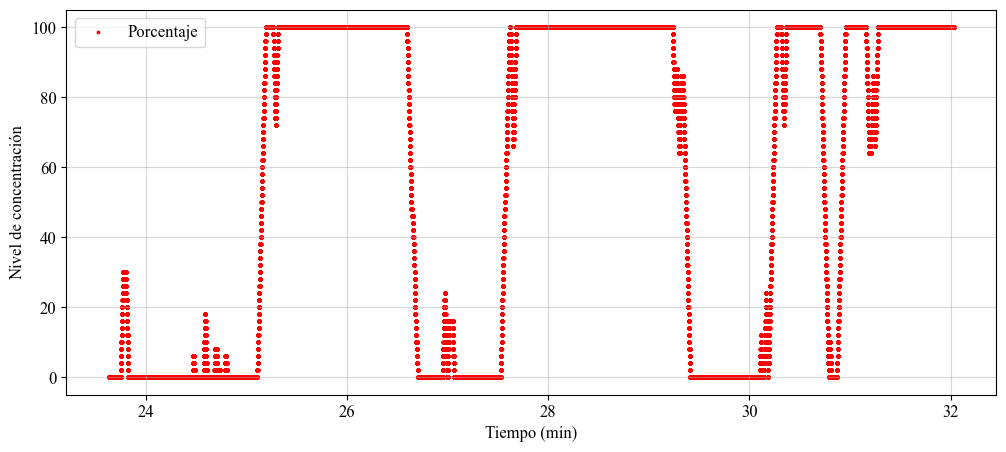

In [ ]:
plt.figure(figsize = (12, 5)) # Modificar el tamaño del gráfico
plt.scatter(df['TimeStamp'], df['Concentration'], s = 3, color = 'red', label = "Porcentaje") # Generamos el gráfico con Tiempo en X y Potencia en Y, y cambiamos el grosor de la línea del gráfico, color y leyenda
plt.xlabel("Tiempo (min)") # Poner nombre al eje x
plt.ylabel("Nivel de concentración") # Poner nombre al eje y
plt.legend()
plt.grid(True, alpha = 0.5) # Colocamos la gráfica del fondo del gráfico y cambiamos la tonalidad (va de 0 a 1)

In [ ]:
# Discriminación de pacientes por nivel de concentracion
resultado = []
for elemento in df["Concentration"]:
    if elemento < 100: # Maximo de concentracion
        resultado.append("Distraido")
    else:
        resultado.append("Concentrado") # solo para máximo (100)
df["concentracion"] = np.array(resultado)

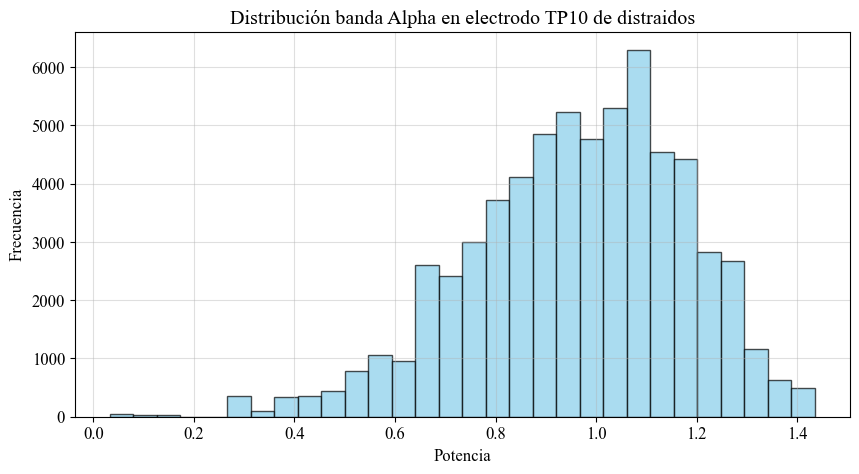

In [ ]:
plt.figure(figsize = (10, 5))
plt.hist(df[df["Concentration"]<100]["Alpha_TP10"], bins = 30, color = "skyblue", edgecolor = "black", alpha = 0.7)
plt.xlabel("Potencia")
plt.ylabel("Frecuencia")
plt.title("Distribución banda Alpha en electrodo TP10 de distraidos")
plt.grid(True, alpha = 0.4)
plt.show()

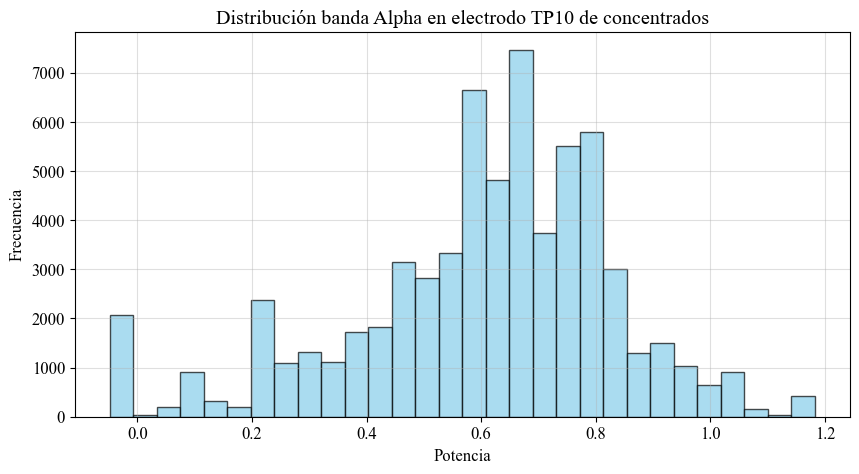

In [ ]:
plt.figure(figsize = (10, 5))
plt.hist(df[df["Concentration"]==100]["Alpha_TP10"], bins = 30, color = "skyblue", edgecolor = "black", alpha = 0.7)
plt.xlabel("Potencia")
plt.ylabel("Frecuencia")
plt.title("Distribución banda Alpha en electrodo TP10 de concentrados")
plt.grid(True, alpha = 0.4)
plt.show()

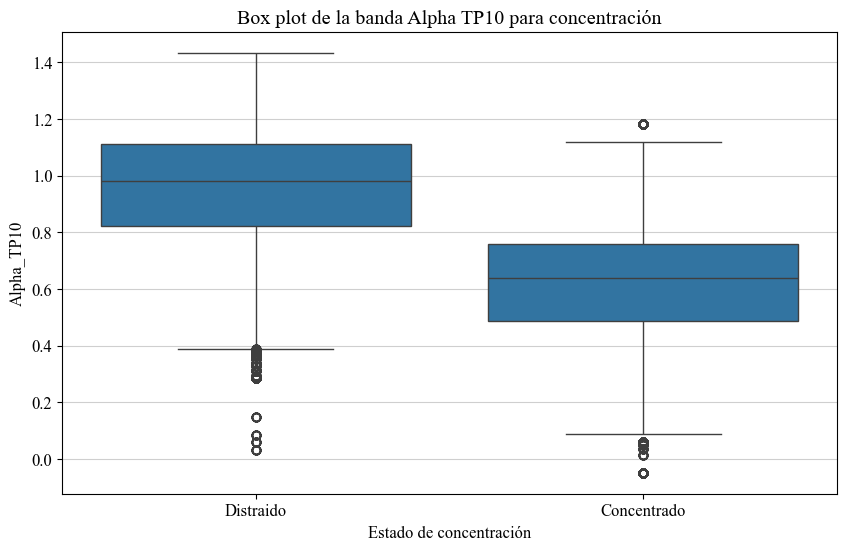

In [ ]:
plt.figure(figsize = (10, 6))
sns.boxplot(data = df, x = "concentracion", y = "Alpha_TP10")
plt.title("Box plot de la banda Alpha TP10 para concentración")
plt.xlabel("Estado de concentración")
plt.grid(True, alpha = 0.6, axis = "y")
plt.show()

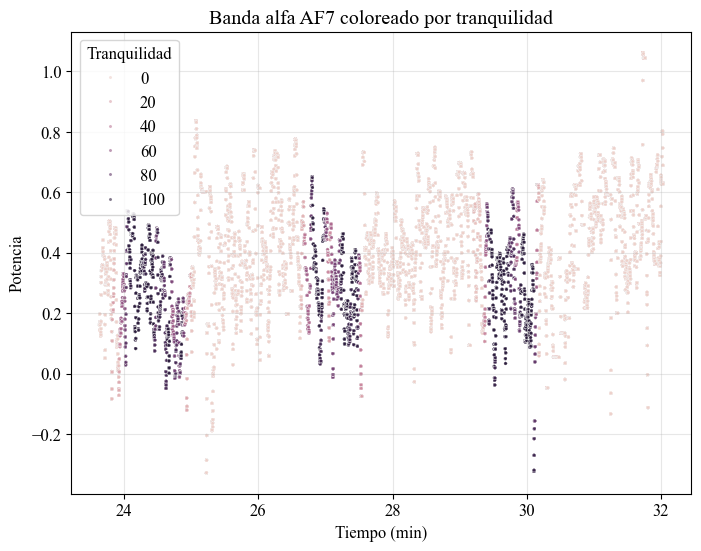

In [ ]:
plt.figure(figsize  = (8,6))
sns.scatterplot(data = df, x = "TimeStamp", y = "Alpha_AF7", hue = "Mellow", alpha = 0.6, s = 5) # Hue es añadir a los puntos una tonalidad de color en función a la tranquilidad
plt.xlabel("Tiempo (min)") # Poner nombre al eje x
plt.ylabel("Potencia") # Poner nombre al eje y
plt.title("Banda alfa AF7 coloreado por tranquilidad") # Poner título a los gráficos
plt.legend(title = "Tranquilidad")
plt.grid(True, alpha = 0.3) # Colocamos la gráfica del fondo del gráfico y cambiamos la tonalidad (va de 0 a 1)
plt.savefig("Banda alfa con hue.png", dpi = 300, bbox_inches = "tight") # Para guardar los gráficos en la carpeta donde está el programa donde lo analizamos. Ponemos el nombre con el formato, dpi es la resolución, que no se guarde con bordes blancos
plt.show()

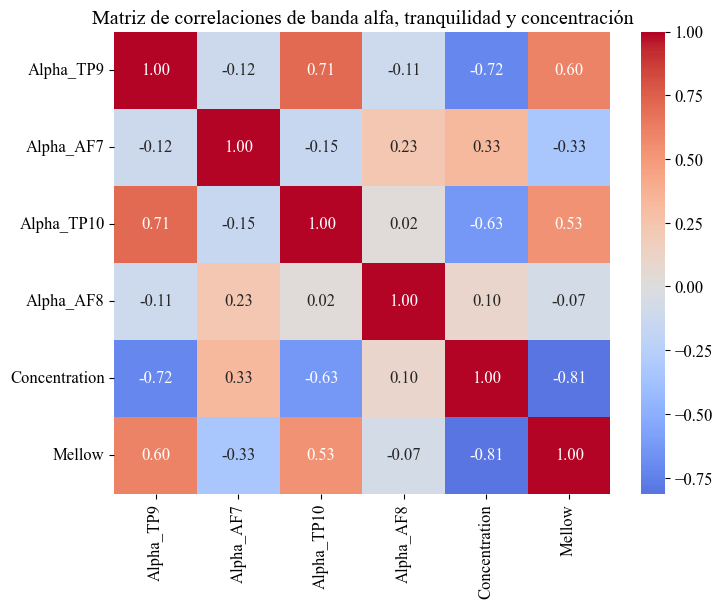

In [ ]:
subset = ["Alpha_TP9", "Alpha_AF7", "Alpha_TP10", "Alpha_AF8", "Concentration", "Mellow"]
corr_subset = df[subset].corr()

plt.figure(figsize = (8,6))
sns.heatmap(corr_subset, annot = True, cmap = "coolwarm", center = 0, fmt = ".2f") # fmt es para que solo de 2 decimales
plt.title("Matriz de correlaciones de banda alfa, tranquilidad y concentración")
plt.show()